In [ ]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMD
from tqdm import tqdm

sys.path.append("../")

from functions.chdsubid import SubIDChangeDetector
from functions.datasets import load_skab
from functions.metrics import chp_score
from functions.preprocessing import Hankelizer
from functions.rolling import Rolling

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Read data
dfs = load_skab("data/skab")
dfs_free = [
    df
    for key, df_group in dfs.items()
    for df in df_group
    if key == "anomaly-free"
]
dfs_: list[pd.DataFrame] = [
    pd.DataFrame(df)
    for key, df_group in dfs.items()
    for df in df_group
    if key != "anomaly-free"
]
for df in dfs_:
    df.index = pd.to_datetime(df.index)

In [ ]:
def compute_interaction_terms(df: pd.DataFrame) -> pd.DataFrame:
    """Add pairwise interaction (product) columns to the dataframe."""
    cols = df.columns
    for i in cols:
        for j in cols:
            if i <= j:
                df[f"{i}*{j}"] = df[i] * df[j]
    return df

In [ ]:
grace_period = 400  # Used in SKAB Leaderboard

In [ ]:
# Prepare arrays for storing results
scores_datasets = []
scores_datasets_alt = []

# Iterate datasets
for i, df in enumerate(dfs_):
    X = df.drop(["anomaly", "changepoint"], axis=1)
    from sklearn.model_selection import train_test_split

    # X = compute_interaction_terms(X)
    X_train, X_test = train_test_split(
        X,
        train_size=grace_period,
        shuffle=False,
    )

    window_size = grace_period
    hn = 60
    r = 6
    ref_size = 60
    test_size = 60
    # Initialize Hankelizer
    hankelizer = Hankelizer(hn)

    # Initialize Transformer
    init_size = grace_period - test_size - 1
    odmd = Rolling(
        OnlineDMD(
            r=r,
            initialize=init_size,
            w=1.0,
            exponential_weighting=True,
            eig_rtol=1e-1,
        ),
        grace_period,
    )

    # Initialize Change-Point Detector
    subid_dmd = SubIDChangeDetector(
        odmd,
        ref_size=ref_size,
        test_size=test_size,
        grace_period=grace_period,
        start_soon=True,
        learn_after_grace=False,
    )

    # Build pipeline
    pipeline_dmd = hankelizer | subid_dmd

    for x in X_train.to_dict(orient="records"):
        pipeline_dmd.learn_one(x)
    # Produces scaled results
    # pipeline_dmd.learn_many(X_train)

    scores_dmd = np.zeros(X_test.shape[0], dtype=float)
    scores_dmd_alt = np.zeros(X_test.shape[0], dtype=float)
    # Run pipeline
    for j, x in tqdm(
        enumerate(X_test.to_dict(orient="records")),
        total=len(X_test),
        mininterval=1.0,
        desc=f"Dataset: {i + 1}/{len(dfs_)}. Snapshots processed",
    ):
        scores_dmd[j] = pipeline_dmd.score_one(x)
        # Although learn one is present, the DMD is not learning from the data
        #  as learn_after_grace=False. Nevertheless the data collection mechanism
        #  is still active and needs to be updated.
        pipeline_dmd.learn_one(x)

        dist = subid_dmd.distances
        scores_dmd_alt[j] = (dist[1] - dist[0]).real

    scores_datasets.append(pd.Series(scores_dmd, index=X_test.index))
    scores_datasets_alt.append(pd.Series(scores_dmd_alt, index=X_test.index))

with Path("results/.skab/skab_scores_datasets-online.pkl").open("wb") as f:
    pickle.dump(scores_datasets, f)

In [ ]:
true_outlier, true_cp = [], []
# Iterate datasets
for _, df in enumerate(dfs_):
    Y = df[["anomaly", "changepoint"]]
    from sklearn.model_selection import train_test_split

    Y_train, Y_test = train_test_split(
        Y,
        train_size=grace_period,
        shuffle=False,
    )
    true_outlier.append(Y_test["anomaly"])
    true_cp.append(Y_test["changepoint"])
if "scores_datasets" not in locals():
    with Path("results/.skab/skab_scores_datasets-online.pkl").open("rb") as f:
        scores_datasets = pickle.load(f)  # noqa: S301  # trusted local pickle generated by this project

In [ ]:
experiments: dict[str, list] = {
    "Perfect detector": true_outlier,
    "Random detector": [
        pd.Series(np.random.randint(2, size=df.shape[0]), index=df.index)
        for df in dfs_
    ],
    "Null detector": [
        pd.Series(np.zeros(df.shape[0]), index=df.index) for df in dfs_
    ],
    "Always positive": [
        pd.Series(np.ones(df.shape[0]), index=df.index) for df in dfs_
    ],
    "Online DMD (t=0)": [sd > 0.0 for sd in scores_datasets],
    "Online DMD (t=0.5)": [sd > 0.005 for sd in scores_datasets],
    "Online DMD": [sd > 0.0025 for sd in scores_datasets],
}

window_params = {
    "valid": {
        "window_width": "60s",
        "anomaly_window_destination": "righter",
    },
    "compliant": {
        "window_width": "30s",
        "anomaly_window_destination": "center",
    },
}

metrics = [
    "F1",
    "FAR",
    "MAR",
    "Delay",
    "TP",
    "FN",
    "FP",
    "Standard",
    "LowFP",
    "LowFN",
]

df_res = pd.DataFrame(
    columns=pd.Index([f"{m} ({p})" for p in window_params for m in metrics]),
    index=pd.Index(list(experiments.keys())),
)

for name, pos in experiments.items():
    pcs = [po.astype(int).diff().abs().fillna(0) for po in pos]
    res = {}
    for window_name, kwargs in window_params.items():
        binary = chp_score(
            true_outlier,
            pos,
            metric="binary",
        )
        add = chp_score(
            true_cp,
            pcs,
            metric="average_time",
            window_width=kwargs["window_width"],
            anomaly_window_destination=kwargs["anomaly_window_destination"],
        )
        nab = chp_score(
            true_cp,
            pcs,
            metric="nab",
            window_width=kwargs["window_width"],
            anomaly_window_destination=kwargs["anomaly_window_destination"],
        )
        res_ = dict(zip(["F1", "FAR", "MAR"], binary, strict=False))
        res_.update(dict(zip(["Delay", "FN", "FP", "TP"], add, strict=False)))
        res_.update(nab)
        res_ = {f"{k} ({window_name})": v for k, v in res_.items()}
        res.update(res_)
    df_res.loc[name] = res

df_res.sort_values("Standard (valid)", ascending=False)

# Visualize results

In [ ]:
def plot_results(
    *true_pred_pairs: tuple[pd.Series, pd.Series],
    reset_index: bool = False,
) -> None:
    """Plot true and predicted series side-by-side for each provided pair."""
    n = len(true_pred_pairs)
    _fig, axs = plt.subplots(n, 1, figsize=(12, 3 * n))
    if n == 1:
        axs = [axs]

    for ax, (true, pred) in zip(axs, true_pred_pairs, strict=False):
        if reset_index:
            true_ = true.reset_index(drop=True)
            pred_ = pred.reset_index(drop=True)
        ax.plot(
            true_ if reset_index else true,
            label="True",
            marker="o",
            markersize=5,
        )
        axx = ax.twinx()
        axx.plot(
            pred_ if reset_index else pred,
            label="Predicted",
            marker="x",
            markersize=5,
            color=ax._get_lines.get_next_color(),
        )
        ax.grid()

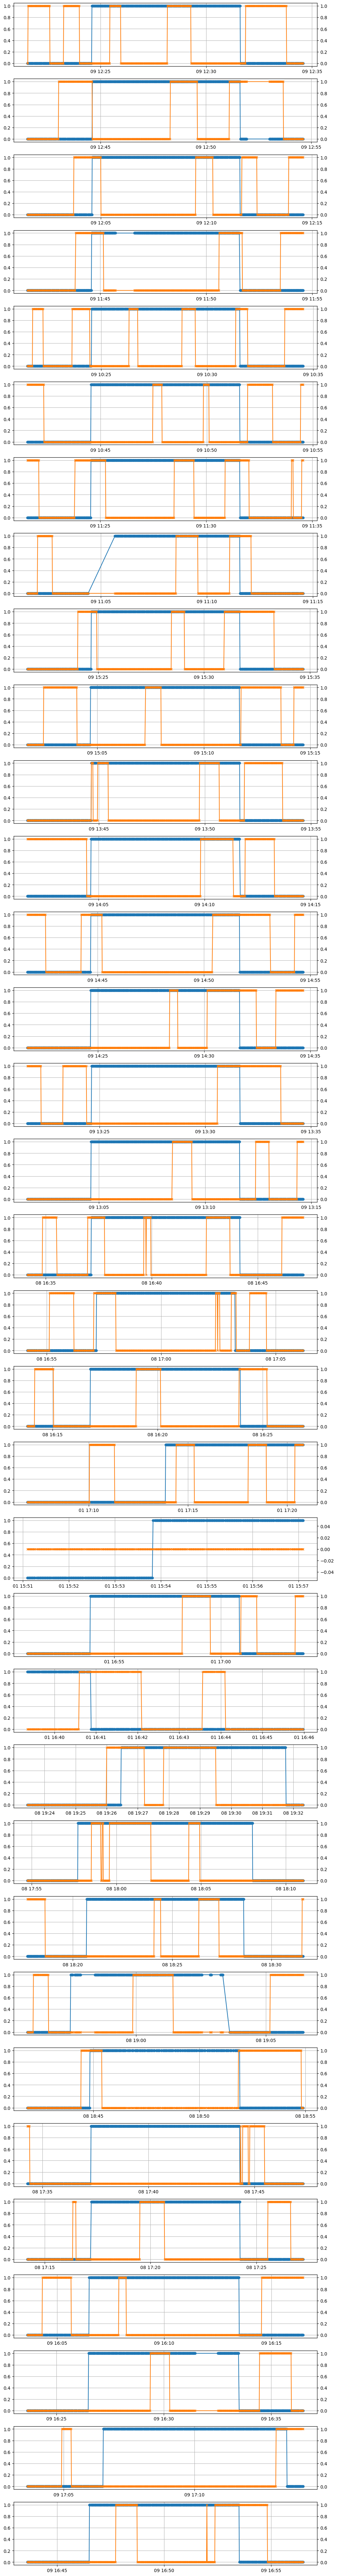

In [ ]:
# [donotremove]
plot_results(*list(zip(*(true_outlier, pos), strict=False)))

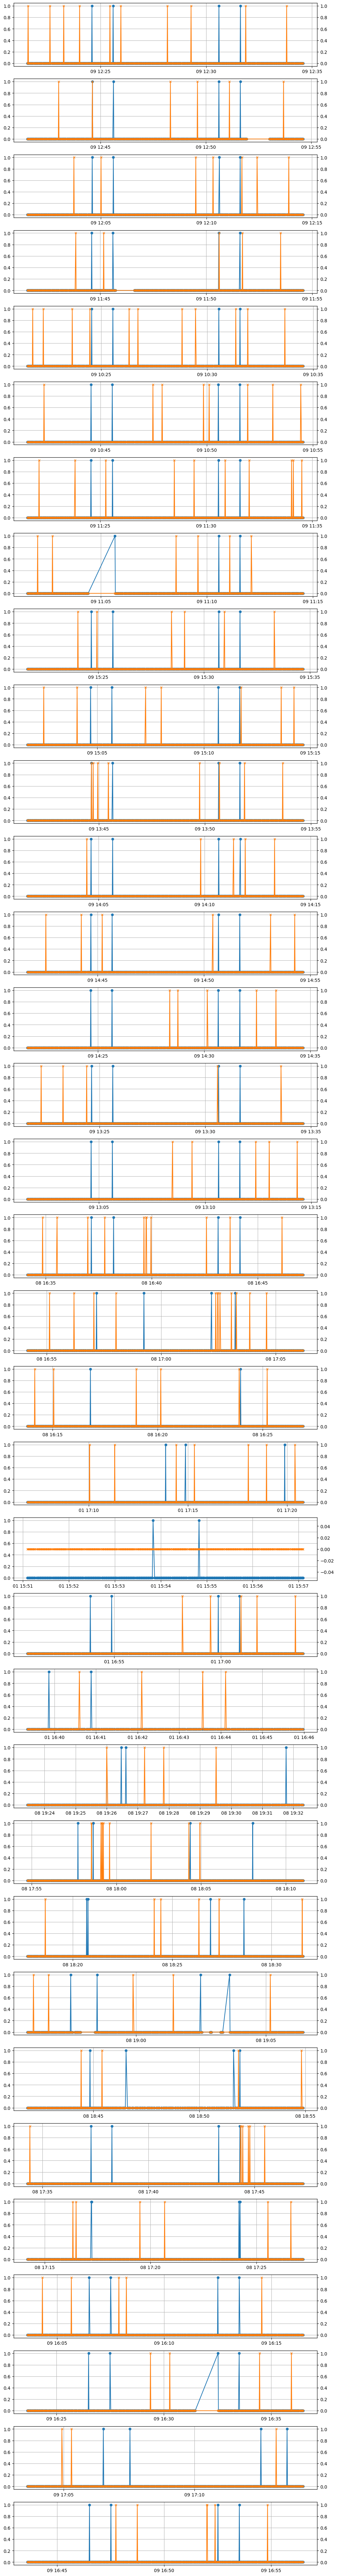

In [ ]:
# [donotremove]
plot_results(*list(zip(*(true_cp, pcs), strict=False)))

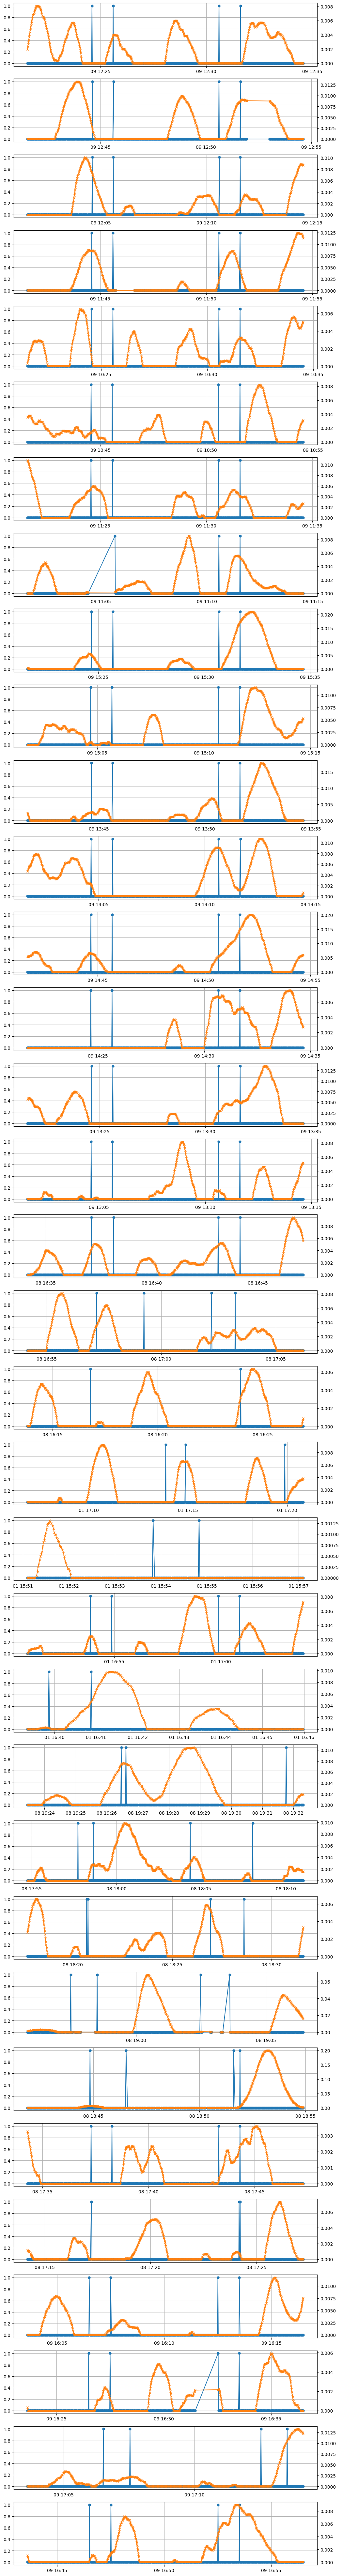

In [ ]:
# [donotremove]
plot_results(*list(zip(*(true_cp, scores_datasets), strict=False)))